# Gene Ontology enrichment Analysis(GOEA) Pipeline 

**Author:** Yong Gyu Kim </br>
**Last Updated:** 2025-10-16 </br>
**Contact:** parkgilbong@gmail.com </br>

## Pipeline Overview

This Jupyter Notebook orchestrates a comprehensive workflow for **Gene Ontology (GO) Enrichment Analysis** on RNA-Seq data. It is designed to take raw differential expression results, identify significant genes, and determine which biological processes, cellular components, and molecular functions are over-represented.

This workflow is built for modularity, reproducibility, and automation. Each analysis step is a self-contained Python script, with all parameters controlled by a centralized YAML configuration file.

### Key Features ✨

* **Dynamic & Reproducible Runs:** For every execution, a unique, timestamped output folder is created (e.g., `output/GO_pipeline_Shank2_2025-10-17_00-30-00/`). This folder contains all results, logs, and the exact configuration file used for the run, guaranteeing perfect reproducibility.
* **Integrated Logging:** All output from the notebook and every script it calls is captured in a single, consolidated log file (`pipeline_run.log`) located within the unique output folder. This makes it easy to track the entire process and debug any issues.
* **Centralized Configuration:** All parameters—from input files and statistical cutoffs to plot settings—are managed in a single YAML file. This allows you to easily adapt the pipeline to new datasets without changing any code.
* **Comprehensive GO Analysis:** The pipeline automatically performs GO enrichment analysis on differentially expressed genes (DEGs), typically splitting them into up-regulated, down-regulated, and combined lists.
* **Automated Visualization & Reporting:** The workflow automatically generates key visualizations like Volcano plots and GO term bar plots, and compiles all results into a final, comprehensive HTML report for easy interpretation.

---

## How to Use This Pipeline 🚀

### Step 1: Prepare Your Configuration File

1.  Choose a base configuration file from the `configs/` directory (e.g., `GO_pipeline_Shank2.yaml`) to use for your project.
2.  Open the file and carefully edit the parameters for each section. Pay close attention to:
    * **`data_loading`**: Specify the path to your raw data Excel file and the names of the required columns (`gene_col`, `log2fc_col`, etc.). If you plan to run Classic GSEA, also define the `gsea_outputs` section with your sample columns.
    * **`filtering`**: Set the thresholds (log2fc_threshold and pval_threshold) for identifying significant differentially expressed genes.
    * **`go_enrich`**: This is crucial. Provide the path to your background_csv file (typically the standardized.csv from the loading step) and the paths to your GO annotation files (obo and gaf).
    * **`go_barplot`**: Adjust parameters like the number of terms to plot (top_n_terms).

### Step 2: Set the Base Configuration in the Notebook
In the first code cell of this notebook (labeled "Pipeline Initialization"), make sure the BASE_CONFIG_PATH variable points to the YAML file you just prepared.

```Python
# Make sure this path points to your GO pipeline config file!
BASE_CONFIG_PATH = Path("./configs/GO_pipeline_Shank2.yaml")
```

### Step 3: Run the Notebook Cells Sequentially
* Execute the cells one by one.
    - Cell 1 (Pipeline Initialization): This is the most important step. It will create the unique output folder, set up the logging system, and generate the final `run_config.yaml` that all subsequent steps will use.
    - Subsequent Cells: Each cell calls a specific analysis script (`data_loading.py`, `filtering.py`, etc.), passing it the path to the run_config.yaml file. Follow the markdown instructions provided above each cell.

### Step 4: Find Your Results
* Once the notebook has finished, navigate to the unique output folder created in `output/`. Inside, you will find all your results neatly organized, including:
    - `run_config.yaml`: The exact settings used for this analysis.
    - `pipeline_run.log`: A complete log of the entire workflow.
    - `standardized.csv`: The processed input data.
    - `filtered.csv`: The list of significant DEGs.
    - `goea_results_up.csv`, `goea_results_down.csv`: The GO enrichment results for up- and down-regulated genes.
    - `volcano.png`: The volcano plot of your differential expression data.
    - `go_barplot_up.png`, `go_barplot_down.png`: Bar plots of the top enriched GO terms.
    - `report.html`: The final, automatically generated HTML summary report.

---



## 1. Pipeline Initialization
These first cells are the control center for your entire analysis run. 🚀

Before you run it, please double-check that the `BASE_CONFIG_PATH` variable points to the correct base YAML configuration file you want to use for this analysis.

When you execute this cell, it will automatically:

1. Create a unique, timestamped output folder inside the output/ directory. This ensures that every run is saved separately and nothing is ever overwritten.

2. Set up the integrated logging system. A pipeline_run.log file will be created inside the new output folder. All messages from this notebook and every script it calls will be saved to this single file.

3. Generate the final run_config.yaml file for this specific run and save it inside the output folder. This file contains the exact settings used, ensuring your analysis is perfectly reproducible.

Simply run the cell below to get started

In [1]:
import os
import yaml
import logging
from datetime import datetime
from pathlib import Path

from IPython.display import Image, display
from utils.logging_utils_environ import setup_logging

# --- 1. Define Base Configuration ---
BASE_CONFIG_PATH = Path("../configs/GO_pipeline_Shank2.yaml") # Change this to your desired base config file
PIPELINE_NAME = BASE_CONFIG_PATH.stem

# --- 2. Create a Unique Timestamped Output Directory for this Run ---
# This folder will contain EVERYTHING for this run: results, logs, and the config.
PROJECT_ROOT = Path.cwd().parent
print(f"Project root = {PROJECT_ROOT}")
timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
run_output_dir = PROJECT_ROOT / f"output/{PIPELINE_NAME}_{timestamp}"
run_output_dir.mkdir(parents=True, exist_ok=True)

# --- 3. Set Up Logging to Save Inside the Unique Output Directory ---
log_file_path = run_output_dir / "pipeline_run.log"
os.environ['PIPELINE_LOG_FILE'] = str(log_file_path)
logger, _ = setup_logging()

# --- 4. Create the Final, Dynamic Configuration for this Run ---
# Read the base settings
with open(BASE_CONFIG_PATH, 'r', encoding='utf-8') as f:
    config_data = yaml.safe_load(f)

# Dynamically set the 'ROOT_DIR' to our unique output folder
config_data['ROOT_DIR'] = str(run_output_dir)

# Define the final path for the config file for THIS RUN.
# No more temp files!
RUN_CONFIG_PATH = run_output_dir / "run_config.yaml"

# Save the final, complete config file directly into the output directory.
with open(RUN_CONFIG_PATH, 'w', encoding='utf-8') as f:
    yaml.dump(config_data, f, default_flow_style=False, sort_keys=False)

# --- 5. Final Confirmation ---
logger.info(f"✅ Pipeline '{PIPELINE_NAME}' run initialized.")
logger.info(f"📂 All results, logs, and the exact config used will be saved in:\n{run_output_dir.resolve()}")

# This CONFIG_PATH variable is now the single source of truth for this run.
# It will be used by all subsequent cells in the notebook.
CONFIG_PATH = str(RUN_CONFIG_PATH)

Project root = c:\Users\KimYG\Documents\GitHub\RNA-Seq_GO_analysis
2025-10-16 17:37:18,428 | MyAnalysisLogger | INFO | Attached to pipeline log file: c:\Users\KimYG\Documents\GitHub\RNA-Seq_GO_analysis\output\GO_pipeline_Shank2_2025-10-16_17-37-18\pipeline_run.log
2025-10-16 17:37:18,521 | MyAnalysisLogger | INFO | ✅ Pipeline 'GO_pipeline_Shank2' run initialized.
2025-10-16 17:37:18,524 | MyAnalysisLogger | INFO | 📂 All results, logs, and the exact config used will be saved in:
C:\Users\KimYG\Documents\GitHub\RNA-Seq_GO_analysis\output\GO_pipeline_Shank2_2025-10-16_17-37-18


In [ ]:
# Environment setup (paths, PYTHONPATH, folders)
# 1. 프로젝트의 최상위 경로(PROJECT_ROOT)를 정의합니다.
# 현재 노트북 파일이 있는 폴더를 기준으로 경로를 설정합니다.
# PROJECT_ROOT = Path.cwd().parent  # NOTE: 하위 폴더에서 실행 시 적절히 조정

# 2. 실행할 스크립트와 설정 파일의 절대 경로를 동적으로 생성합니다.
CONFIG_DIR = PROJECT_ROOT / "configs"
RESULTS_DIR = PROJECT_ROOT / "results"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
# CONFIG_PATH = CONFIG_DIR / "GO_pipeline_H2O2.yaml"
SRC_DIR = PROJECT_ROOT / "src" / "analysis"

data_loading_PATH = SRC_DIR / "data_loading.py"
filter_PATH = SRC_DIR / "filtering.py"
volcano_PATH = SRC_DIR / "volcano.py"
goea_PATH = SRC_DIR / "go_enrich.py"
go_barplot_PATH = SRC_DIR / "go_barplot.py"
report_PATH = SRC_DIR / "report_generation.py"
compare_degs_PATH = SRC_DIR / "compare_degs.py"
gene_filter_analysis_PATH = SRC_DIR / "gene_filter_analysis.py"

for d in (CONFIG_DIR, RESULTS_DIR, PROCESSED_DIR):
    d.mkdir(parents=True, exist_ok=True)

logger.info(f"Project root = {PROJECT_ROOT}")
logger.info(f"Config path = {CONFIG_PATH}")

2025-10-16 17:37:26,658 | MyAnalysisLogger | INFO | Project root = c:\Users\KimYG\Documents\GitHub\RNA-Seq_GO_analysis
2025-10-16 17:37:26,665 | MyAnalysisLogger | INFO | Config path = c:\Users\KimYG\Documents\GitHub\RNA-Seq_GO_analysis\output\GO_pipeline_Shank2_2025-10-16_17-37-18\run_config.yaml


## 2. Standardize data (Excel -> CSV)
This cell executes the data loading and preparation step. 🧹

It runs the `data_loading.py` script, which uses the `run_config.yaml` file created in the previous step. The script will:

* Read your raw data from the Excel file specified in the config.

* Standardize the column names to `gene`, `log2fc`, and `padj` while keeping all other original columns.

* Save the processed data as `standardized.csv` inside your unique output folder.

In [ ]:
command_dl = f"python {data_loading_PATH} --config {CONFIG_PATH} --config-section data_loading"
logger.info(f"✅ 실행 명령어: \n{command_dl}")
!{command_dl}

2025-10-16 17:37:33,080 | MyAnalysisLogger | INFO | Attached to pipeline log file: c:\Users\KimYG\Documents\GitHub\RNA-Seq_GO_analysis\output\GO_pipeline_Shank2_2025-10-16_17-37-18\pipeline_run.log
2025-10-16 17:37:40,882 | MyAnalysisLogger | INFO | Loaded rows=14237 from files=1
2025-10-16 17:37:41,366 | MyAnalysisLogger | INFO | Saved standardized data to: c:\Users\KimYG\Documents\GitHub\RNA-Seq_GO_analysis\output\GO_pipeline_Shank2_2025-10-16_17-37-18\standardized.csv
2025-10-16 17:37:41,366 | MyAnalysisLogger | INFO | GSEA output generation is enabled.
2025-10-16 17:37:41,736 | MyAnalysisLogger | INFO | Successfully saved GSEA expression matrix to: c:\Users\KimYG\Documents\GitHub\RNA-Seq_GO_analysis\output\GO_pipeline_Shank2_2025-10-16_17-37-18\gsea_expression_matrix.txt
2025-10-16 17:37:41,739 | MyAnalysisLogger | INFO | Successfully saved GSEA class labels to: c:\Users\KimYG\Documents\GitHub\RNA-Seq_GO_analysis\output\GO_pipeline_Shank2_2025-10-16_17-37-18\gsea_class_labels.cls


In [16]:
import pandas as pd
from pathlib import Path as _P

std_csv = f"{run_output_dir}/standardized.csv"
if _P(std_csv).exists():
    df_std = pd.read_csv(std_csv)
    display(df_std.head())
    print("rows:", len(df_std))
else:
    print("Missing", std_csv, "- check your config paths.")

,gene,log2fc,padj,HGNC symbol,Ensemble ID,baseMean,FC,p-value,HT1,HT2,HT3,HT4,HT5,WT1,WT2,WT3,WT4,WT5,source_file,source_sheet
0,Shank2,-0.498995,0.000024,SHANK2,ENSMUSG00000037541,6705.754801,-1.413229,2.560622e-09,6167.020884,6970.171866,6503.145544,6756.092005,7139.781890,9356.939549,9144.554630,8583.970218,9354.286839,10950.033061,Shank2_RNA-seq_result.xlsx,3W-HT
1,Mdp1,-0.234264,0.014194,MDP1,ENSMUSG00000002329,878.063862,-1.176307,3.260609e-06,847.921190,795.825358,804.353733,784.550125,796.432588,878.234222,962.269843,936.598108,1001.725429,960.577350,Shank2_RNA-seq_result.xlsx,3W-HT
2,Cp,0.471499,0.014194,CP,ENSMUSG00000003617,380.069084,1.386550,3.809525e-06,548.670190,488.395429,446.249349,382.742724,457.793586,361.647239,320.888916,346.237629,294.959900,352.496773,Shank2_RNA-seq_result.xlsx,3W-HT
3,4931414P19Rik,0.839199,0.019994,C14orf93,ENSMUSG00000022179,109.838315,1.789057,6.439643e-06,158.660565,169.790417,118.934073,126.769365,132.514145,62.507250,86.306754,78.027874,97.502948,70.947736,Shank2_RNA-seq_result.xlsx,3W-HT
4,Cep350,0.296934,0.021604,CEP350,ENSMUSG00000033671,1911.016456,1.228531,8.117833e-06,1868.897537,2249.094444,2359.417652,2122.690930,2141.156104,1816.324404,1712.700316,1717.873960,1833.646575,1659.744362,Shank2_RNA-seq_result.xlsx,3W-HT


rows: 14237


## 3. Filter genes
This cell identifies the most significant genes from your dataset and visualizes the results. It executes two scripts in sequence.

First, it runs `filtering.py`, which will:

* Filter the `standardized.csv` file based on the `log2fc_threshold` and `pval_threshold` you set in the config.

* Save the list of significant Differentially Expressed Genes (DEGs) to `filtered.csv`.

* Create separate text files for `filtered_up_genes`.txt and `filtered_down_genes.txt`.

Second, it runs `volcano.py` to generate a **Volcano Plot**, providing a clear visual overview of your differentially expressed genes. The resulting `volcano.png` will be saved in your output folder.

In [4]:
command_filt = f"python {filter_PATH} --config {CONFIG_PATH} --config-section filtering"
logger.info(f"✅ 실행 명령어: \n{command_filt}")
!{command_filt}

2025-10-16 17:37:57,524 | MyAnalysisLogger | INFO | ✅ 실행 명령어: 
python c:\Users\KimYG\Documents\GitHub\RNA-Seq_GO_analysis\src\analysis\filtering.py --config c:\Users\KimYG\Documents\GitHub\RNA-Seq_GO_analysis\output\GO_pipeline_Shank2_2025-10-16_17-37-18\run_config.yaml --config-section filtering
2025-10-16 17:37:59,231 | MyAnalysisLogger | INFO | Attached to pipeline log file: c:\Users\KimYG\Documents\GitHub\RNA-Seq_GO_analysis\output\GO_pipeline_Shank2_2025-10-16_17-37-18\pipeline_run.log
2025-10-16 17:37:59,808 | MyAnalysisLogger | INFO | Filtered(thresholds): n=8
2025-10-16 17:37:59,826 | MyAnalysisLogger | INFO | Saved: c:\Users\KimYG\Documents\GitHub\RNA-Seq_GO_analysis\output\GO_pipeline_Shank2_2025-10-16_17-37-18\filtered.csv


In [5]:
filt_csv = f"{run_output_dir}/filtered.csv"
if _P(filt_csv).exists():
    df_filt = pd.read_csv(filt_csv)
    display(df_filt.head())
    print(
        "rows:", len(df_filt),
        " | up:", int((df_filt.log2fc > 0).sum()),
        " | down:", int((df_filt.log2fc < 0).sum()),
    )
else:
    print("Missing", filt_csv)

NameError: name '_P' is not defined

## 4. Create Volcano Plot


In [ ]:
command_volc = f"python {volcano_PATH} --config {CONFIG_PATH} --config-section volcano"
logger.info(f"Executing command: \n{command_volc}")
!{command_volc}

2025-10-16 17:38:10,910 | MyAnalysisLogger | INFO | ✅ 실행 명령어: 
python c:\Users\KimYG\Documents\GitHub\RNA-Seq_GO_analysis\src\analysis\volcano.py --config c:\Users\KimYG\Documents\GitHub\RNA-Seq_GO_analysis\output\GO_pipeline_Shank2_2025-10-16_17-37-18\run_config.yaml --config-section volcano
2025-10-16 17:38:13,160 | MyAnalysisLogger | INFO | Attached to pipeline log file: c:\Users\KimYG\Documents\GitHub\RNA-Seq_GO_analysis\output\GO_pipeline_Shank2_2025-10-16_17-37-18\pipeline_run.log
2025-10-16 17:38:15,357 | MyAnalysisLogger | INFO | Saved: c:\Users\KimYG\Documents\GitHub\RNA-Seq_GO_analysis\output\GO_pipeline_Shank2_2025-10-16_17-37-18\volcano.png


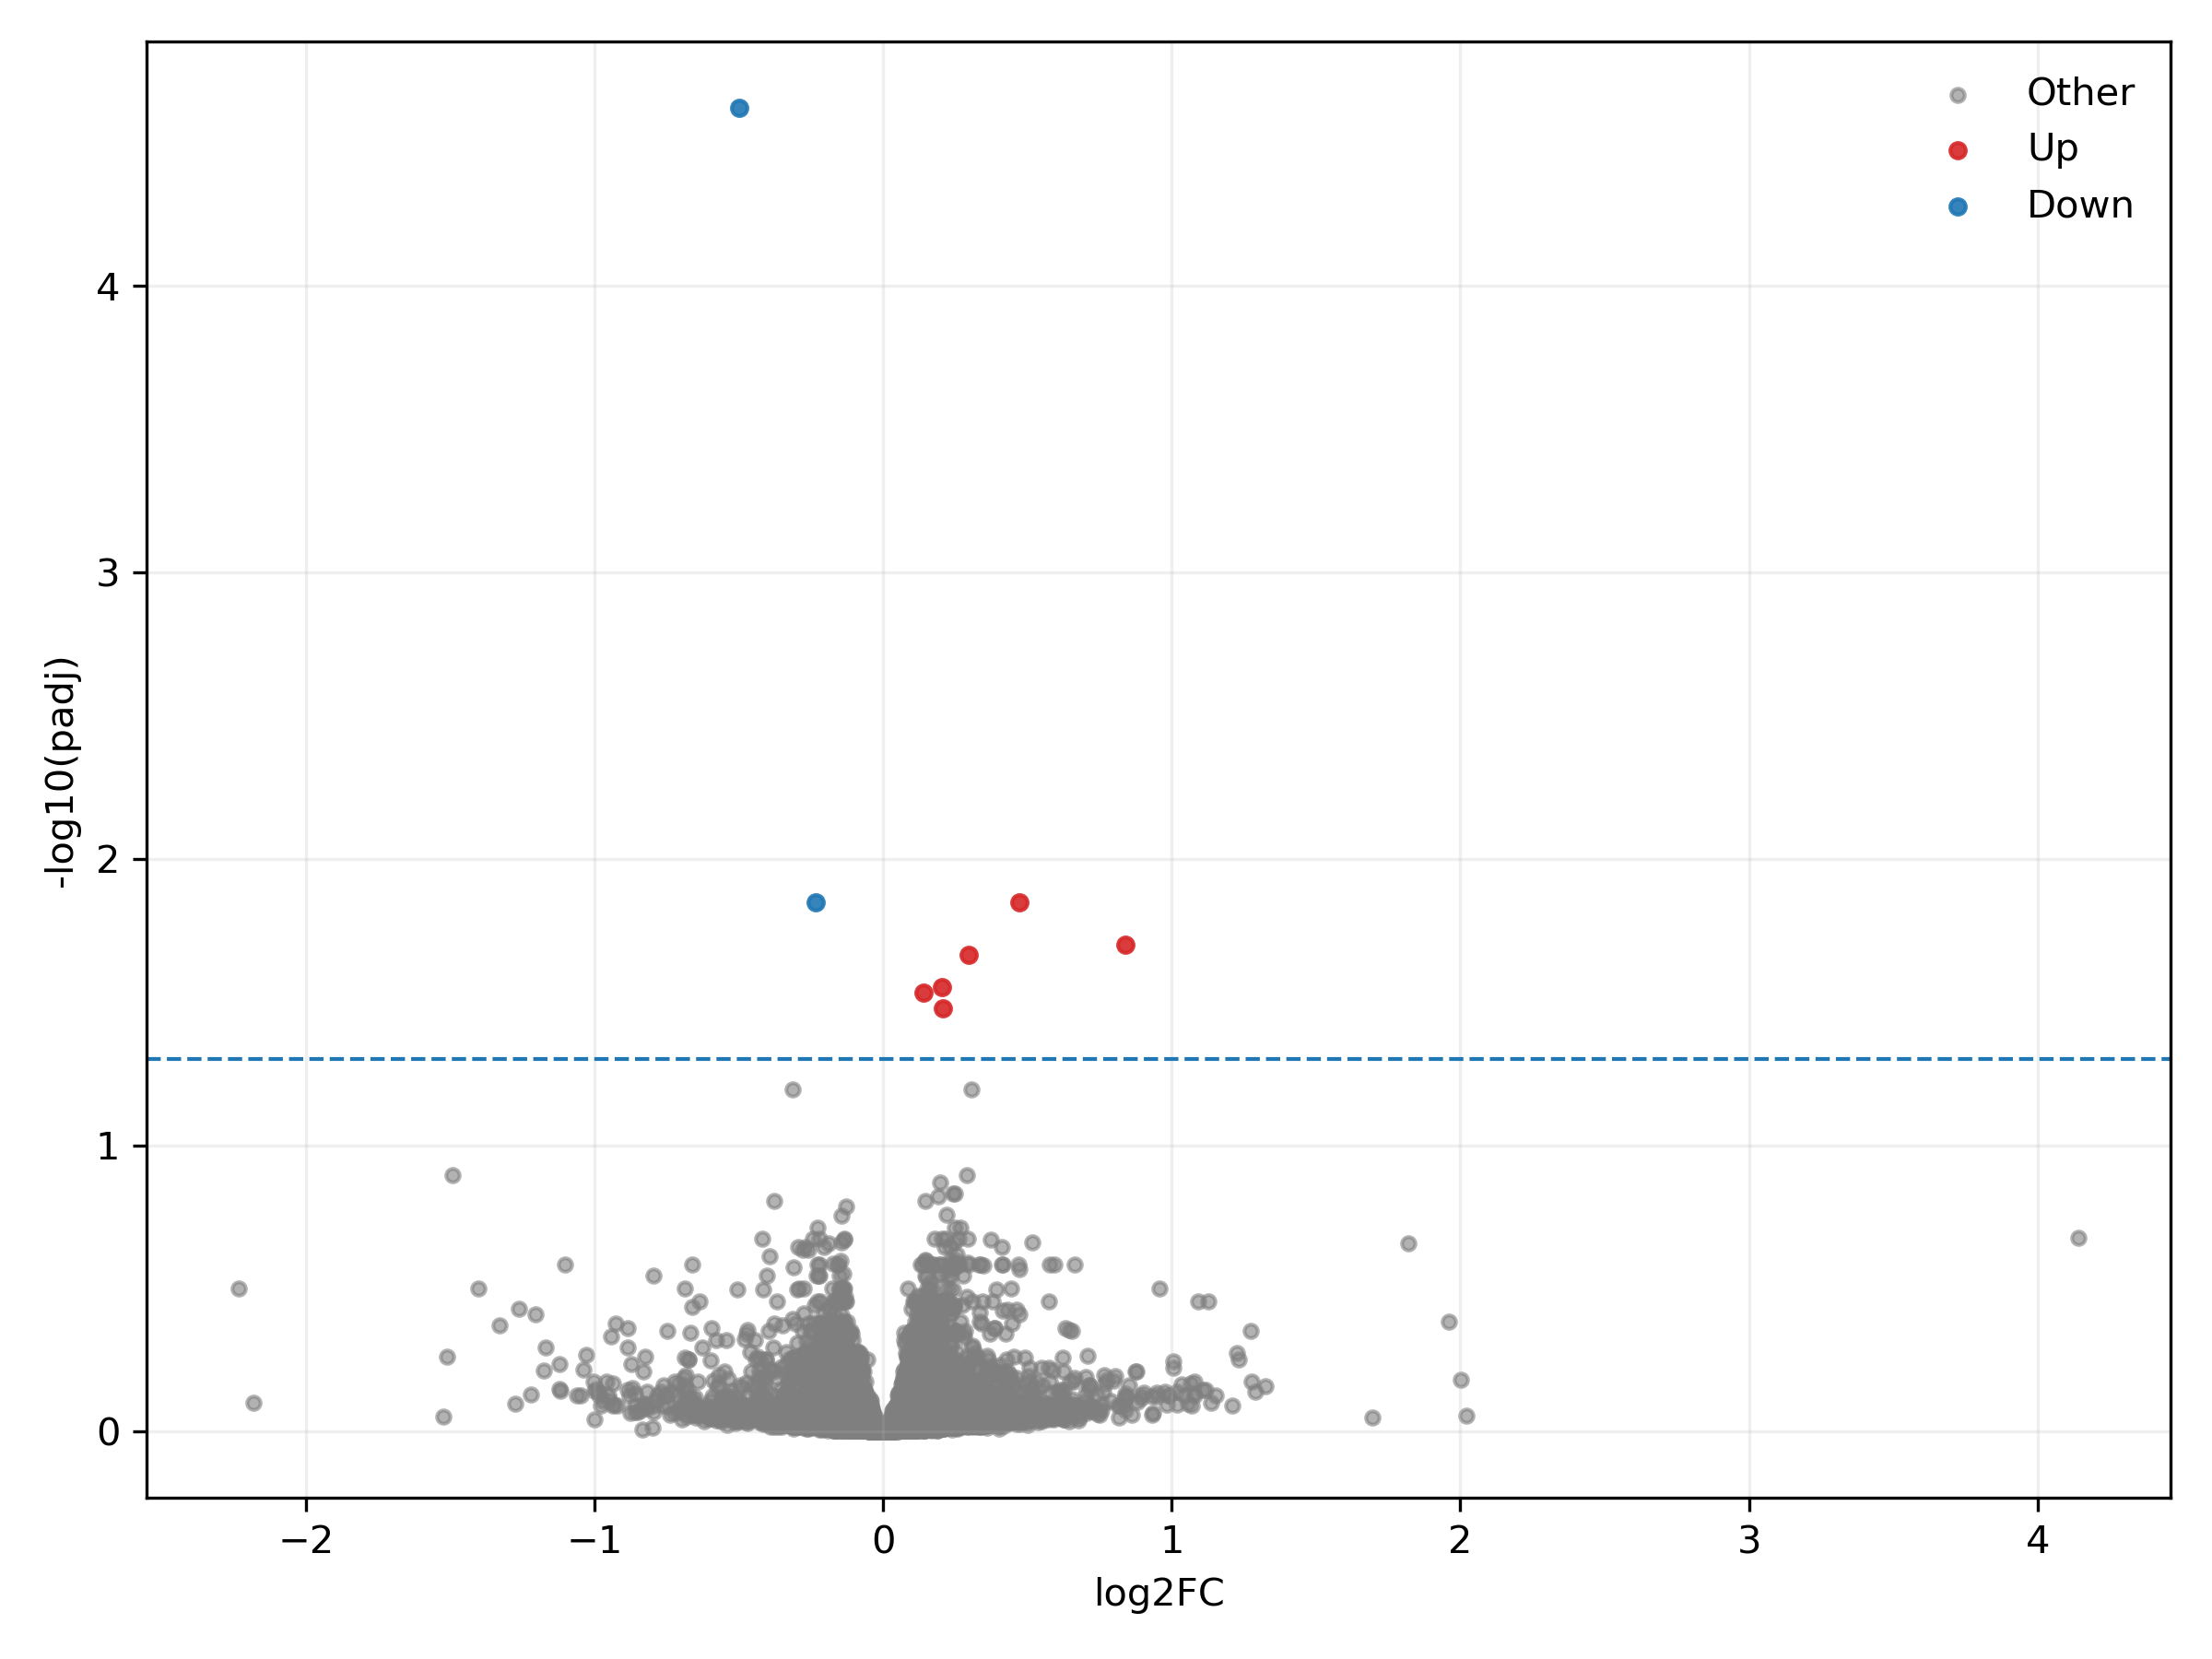

In [8]:
from IPython.display import Image, display
volcano_png = f"{run_output_dir}/volcano.png"
if _P(volcano_png).exists():
    display(Image(filename=volcano_png))
else:
    print("Missing", volcano_png)

## 5. Gene Ontology Enrichment Analysis (GOEA)
This is the core biological interpretation step of the pipeline. 🧬

This cell runs the `go_enrich.py` script. The script takes the up- and down-regulated gene lists generated previously and performs a statistical over-representation analysis to see which GO terms are enriched. It will:

* Run the analysis separately for up-regulated, down-regulated, and all combined DEGs.

* Save the results into detailed CSV files (e.g., `goea_results_up.csv`, `goea_results_down.csv`).

* The detailed progress from the `goatools` library will be fully captured in your `pipeline_run.log` file.

Make sure the paths to your `obo` and `gaf` annotation files are correctly set in your config before running.


In [ ]:
import subprocess

command_goea = f"python {goea_PATH} --config {CONFIG_PATH} --config-section go_enrich"
logger.info(f"Executing command: \n{command_goea}")
!{command_goea}

# 2. subprocess를 사용하여 스크립트를 실행하고, 모든 출력(stdout, stderr)을 캡처합니다.
#    shell=True는 Windows 환경에서 경로 문제를 방지하는 데 도움이 될 수 있습니다.
result = subprocess.run(command_goea, capture_output=True, text=True, encoding='utf-8', shell=True)

# 3. 캡처된 stdout 내용을 한 줄씩 로그에 기록합니다.
if result.stdout:
    logger.info("--- Captured stdout from go_enrich.py ---")
    for line in result.stdout.strip().split('\\n'):
        if line.strip():
            logger.info(line.strip())

# 4. 캡처된 stderr 내용을 한 줄씩 (에러 레벨로) 로그에 기록합니다.
if result.stderr:
    logger.error("--- Captured stderr from go_enrich.py ---")
    for line in result.stderr.strip().split('\\n'):
        if line.strip():
            logger.error(line.strip())

if result.returncode == 0:
    logger.info("go_enrich.py executed successfully.")
else:
    logger.error(f"go_enrich.py failed with return code {result.returncode}.")

2025-10-16 23:49:26,856 | MyAnalysisLogger | INFO | Executing command: 
python c:\Users\KimYG\Documents\GitHub\RNA-Seq_GO_analysis\src\analysis\go_enrich.py --config c:\Users\KimYG\Documents\GitHub\RNA-Seq_GO_analysis\output\GO_pipeline_Shank2_2025-10-16_17-37-18\run_config.yaml --config-section go_enrich


2 GO IDs NOT FOUND IN ASSOCIATION: GO:0140283 GO:0140286
2 GO IDs NOT FOUND IN ASSOCIATION: GO:0140283 GO:0140286
2 GO IDs NOT FOUND IN ASSOCIATION: GO:0140283 GO:0140286


2025-10-16 23:49:28,306 | MyAnalysisLogger | INFO | Attached to pipeline log file: c:\Users\KimYG\Documents\GitHub\RNA-Seq_GO_analysis\output\GO_pipeline_Shank2_2025-10-16_17-37-18\pipeline_run.log
C:\Users\KimYG\Documents\GitHub\RNA-Seq_GO_analysis\ref\go-basic.obo: fmt(1.2) rel(2025-07-22) 43,230 Terms; optional_attrs(relationship)

Load  Ontology Enrichment Analysis ...
Propagating term counts up: is_a
100% 13,458 of 13,458 population items found in association

Runing  Ontology Analysis: current study set of 7 IDs.
100%      7 of      7 study items found in association
100%      7 of      7 study items found in population(13458)
Calculating 20,851 uncorrected p-values using fisher_scipy_stats
  20,851 terms are associated with 13,458 of 13,458 population items
     518 terms are associated with      7 of      7 study items
  METHOD fdr_bh:
       0 GO terms found significant (< 0.05=alpha) (  0 enriched +   0 purified): statsmodels fdr_bh
       0 study items associated with signif

In [18]:
goea_up_csv = f"{run_output_dir}/goea_results_up.csv"
goea_down_csv = f"{run_output_dir}/goea_results_down.csv"
if _P(goea_up_csv).exists():
    df_go = pd.read_csv(goea_up_csv)
    display(df_go.head(10))
    print("rows:", len(df_go))
else:
    print("Missing", goea_up_csv)

if _P(goea_down_csv).exists():
    df_go = pd.read_csv(goea_down_csv)
    display(df_go.head(10))
    print("rows:", len(df_go))
else:
    print("Missing", goea_down_csv)

,GO_ID,NS,Term,study_count,study_n,pop_count,pop_n,p_uncorr,p_adj,depth
0,GO:0008150,BP,biological_process,5,5,13110,13458,1.000000,1.0,0
1,GO:0009987,BP,cellular process,5,5,11421,13458,1.000000,1.0,1
2,GO:0006950,BP,response to stress,4,5,2488,13458,0.004968,1.0,2
3,GO:0050896,BP,response to stimulus,4,5,4080,13458,0.031967,1.0,1
4,GO:0016043,BP,cellular component organization,4,5,4653,13458,0.051652,1.0,3
5,GO:0071840,BP,cellular component organization or biogenesis,4,5,4764,13458,0.056244,1.0,2
6,GO:0050794,BP,regulation of cellular process,4,5,8147,13458,0.654439,1.0,3
7,GO:0050789,BP,regulation of biological process,4,5,8411,13458,0.656609,1.0,2
8,GO:0065007,BP,biological regulation,4,5,8685,13458,0.661880,1.0,1
9,GO:0010467,BP,gene expression,3,5,359,13458,0.000181,1.0,5


rows: 20851


,GO_ID,NS,Term,study_count,study_n,pop_count,pop_n,p_uncorr,p_adj,depth
0,GO:0008150,BP,biological_process,2,2,13110,13458,1.000000,1.0,0
1,GO:0009987,BP,cellular process,2,2,11421,13458,1.000000,1.0,1
2,GO:0030389,BP,fructosamine metabolic process,1,2,3,13458,0.000446,1.0,5
3,GO:0099562,BP,maintenance of postsynaptic density structure,1,2,19,13458,0.002822,1.0,8
4,GO:0071625,BP,vocalization behavior,1,2,21,13458,0.003119,1.0,3
5,GO:0060292,BP,long-term synaptic depression,1,2,22,13458,0.003267,1.0,8
6,GO:0035331,BP,negative regulation of hippo signaling,1,2,24,13458,0.003564,1.0,8
7,GO:0098880,BP,maintenance of postsynaptic specialization str...,1,2,28,13458,0.004157,1.0,7
8,GO:0006040,BP,amino sugar metabolic process,1,2,37,13458,0.005491,1.0,4
9,GO:0097106,BP,postsynaptic density organization,1,2,39,13458,0.005788,1.0,6


rows: 20851


## 6. Create GO Bar Plots
This cell visualizes the GO enrichment results, making them easy to understand at a glance. 📊

It executes the `go_barplot.py` script, which reads the `goea_results_*.csv` files from the previous step. For each result file, it will:

* Select the top enriched GO terms based on p-value.

* Generate a Bar Plot showing these top terms and their significance.

* Save the plots as PNG files (e.g., `go_barplot_up.png`) in your output folder.

The number of terms displayed is controlled by the `top_n_terms` parameter in your config file.

In [ ]:
command_gobar = f"python {go_barplot_PATH} --config {CONFIG_PATH} --config-section go_barplot"
logger.info(f"Executing command: {command_gobar}")
!{command_gobar}

Executing command: python c:\Users\KimYG\Documents\GitHub\RNA-Seq_GO_analysis\src\analysis\go_barplot.py --config c:\Users\KimYG\Documents\GitHub\RNA-Seq_GO_analysis\output\GO_pipeline_Shank2_2025-10-16_17-37-18\run_config.yaml --config-section go_barplot
2025-10-16 23:58:38,113 | MyAnalysisLogger | INFO | Attached to pipeline log file: c:\Users\KimYG\Documents\GitHub\RNA-Seq_GO_analysis\output\GO_pipeline_Shank2_2025-10-16_17-37-18\pipeline_run.log
2025-10-16 23:58:41,003 | MyAnalysisLogger | INFO | Saved: c:\Users\KimYG\Documents\GitHub\RNA-Seq_GO_analysis\output\GO_pipeline_Shank2_2025-10-16_17-37-18\go_barplot_all.png
2025-10-16 23:58:42,172 | MyAnalysisLogger | INFO | Saved: c:\Users\KimYG\Documents\GitHub\RNA-Seq_GO_analysis\output\GO_pipeline_Shank2_2025-10-16_17-37-18\go_barplot_up.png
2025-10-16 23:58:43,682 | MyAnalysisLogger | INFO | Saved: c:\Users\KimYG\Documents\GitHub\RNA-Seq_GO_analysis\output\GO_pipeline_Shank2_2025-10-16_17-37-18\go_barplot_down.png


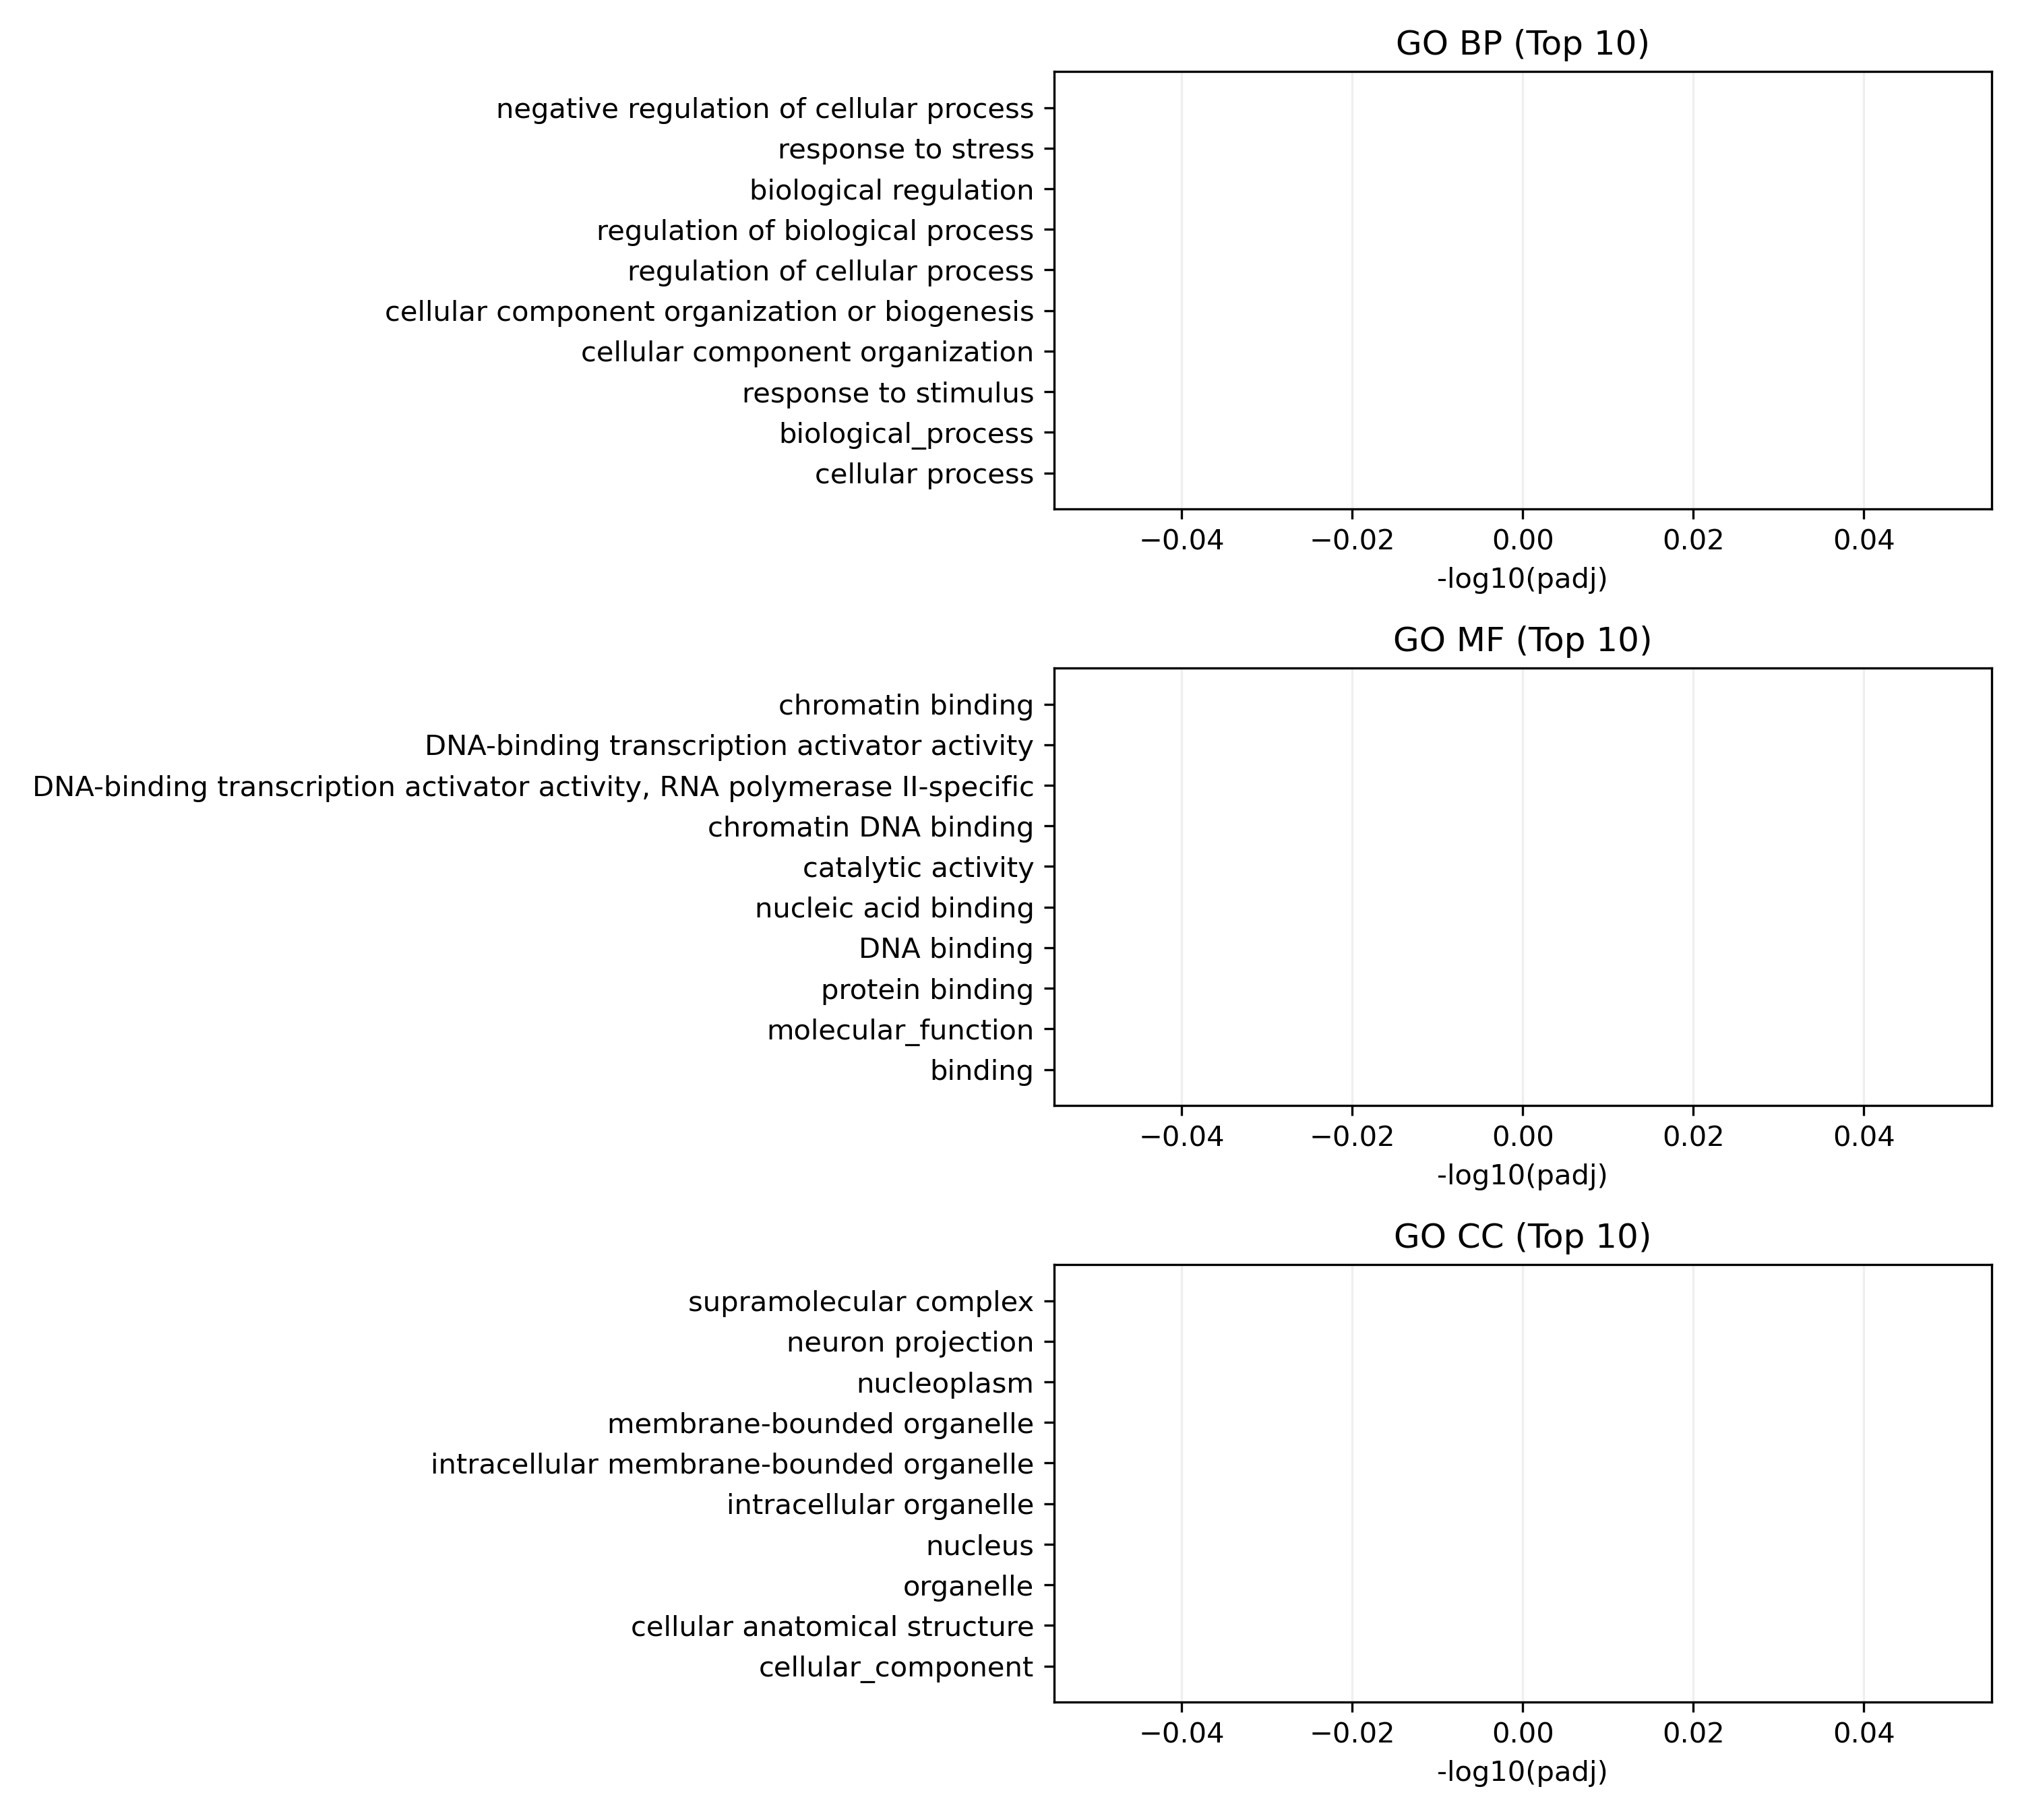

In [20]:
go_bar_png = f"{run_output_dir}/go_barplot_all.png"
if _P(go_bar_png).exists():
    display(Image(filename=go_bar_png))
else:
    print("Missing", go_bar_png)

## 7. Generate Final HTML Report
This is the **final step of the GO pipeline**, which consolidates all of your findings into a single, shareable report. 📄

This cell runs the `report_generation.py` script. It automatically scans your unique output folder, gathers all the previously generated results (Volcano plot, GO bar plots, result tables), and compiles them into a single, easy-to-navigate `report.html` file.

After running this cell, you can open the HTML file in your web browser to see a complete summary of your GO analysis.

In [21]:
command_report = f"python {report_PATH} --config {CONFIG_PATH} --config-section report"
logger.info(f"Executing command: \n{command_report}")
!{command_report}

2025-10-17 00:09:13,128 | MyAnalysisLogger | INFO | Executing command: 
python c:\Users\KimYG\Documents\GitHub\RNA-Seq_GO_analysis\src\analysis\report_generation.py --config c:\Users\KimYG\Documents\GitHub\RNA-Seq_GO_analysis\output\GO_pipeline_Shank2_2025-10-16_17-37-18\run_config.yaml --config-section report
2025-10-17 00:09:14,979 | MyAnalysisLogger | INFO | Attached to pipeline log file: c:\Users\KimYG\Documents\GitHub\RNA-Seq_GO_analysis\output\GO_pipeline_Shank2_2025-10-16_17-37-18\pipeline_run.log
2025-10-17 00:09:15,730 | MyAnalysisLogger | INFO | Saved: c:\Users\KimYG\Documents\GitHub\RNA-Seq_GO_analysis\output\GO_pipeline_Shank2_2025-10-16_17-37-18\report.html


In [13]:
from IPython.display import HTML
report_html = "../data/processed/CHD8/report.html"
if _P(report_html).exists():
    display(HTML(_P(report_html).read_text(encoding="utf-8")))
else:
    print("Missing", report_html)

Missing ../data/processed/CHD8/report.html


## 8) DEG comparison
- 스크립트: `compare_degs.py` (섹션: `deg_comparison`)
- This module provides functionality to compare two lists of differentially expressed genes (DEGs).
- It generates a Venn diagram to visualize the overlap between the two gene sets and a heatmap to compare the log2 fold change values of the common genes.
- The script is configurable via a YAML file and command-line arguments.

In [ ]:
command_compareDEG = f"python {compare_degs_PATH} --config {CONFIG_PATH} --config-section deg_comparison"
print(f"✅ 실행 명령어: {command_compareDEG}")
!{command_compareDEG}

## 9) Gene Filter Analysis (관심 유전자 list에 대한 Dot Plot 생성)
- 스크립트: `gene_filter_analysis.py` (섹션: `gene_filter`)
- This module provides functionality to filter gene expression data from multiple standardized CSV files based on a specific gene list.
- It generates a comparative dot plot visualizing the log2 fold change and adjusted p-values of the selected genes across different datasets.
- The script is configurable via a YAML file and command-line arguments.

In [2]:
command_genefilter = f"python {gene_filter_analysis_PATH} --config {CONFIG_PATH} --config-section gene_filter"
print(f"✅ 실행 명령어: {command_genefilter}")
!{command_genefilter}

✅ 실행 명령어: python c:\Users\KimYG\Documents\GitHub\RNA-Seq\src\analysis\gene_filter_analysis.py --config c:\Users\KimYG\Documents\GitHub\RNA-Seq\configs\GO_pipeline_H2O2.yaml --config-section gene_filter
분석 완료. 결과가 다음 경로에 저장되었습니다: ../data/processed/H2O2\output/gene_filter_analysis


## 8. Batch processing (For Multiple Samples)

This section describes how to run the entire GO pipeline automatically for multiple samples at once using the powerful `batch_runner.py` script. This is the ideal method for high-throughput analysis when you have many different samples or conditions to process with similar settings.

### When to Use Batch Processing 🤖
* When you have multiple datasets (e.g., different time points, treatments, or biological replicates) to analyze.
* When you want to run the exact same analysis pipeline on all your samples in an unattended, automated fashion.
* When you need to slightly modify parameters for each sample (e.g., use a different input file) while keeping the rest of the pipeline settings the same.

### How It Works
The `batch_runner.py` script acts as an automated "pipeline manager." It reads a special YAML file called a manifest (`configs/batch_manifest.yaml`) which you create. This manifest tells the runner:

1. Which base configuration file to use for the default settings.
2. A list of samples to process.
3. Any sample-specific overrides (e.g., a different input file path for each sample).

For each sample in the list, the script dynamically merges the base config with the specific overrides and runs the entire sequence of analysis steps defined in the manifest's `pipeline_steps` section.

### How to Run
#### Step 1: Create or Edit Your Manifest File

Open a manifest file (e.g., `configs/batch_manifest_Shank2.yaml`) and configure it for your batch run. Here is an example structure:

``` YAML
# 1. Path to the base configuration file with default settings
base_config_path: "configs/GO_pipeline_Shank2.yaml"

# 2. List of analysis steps to run for EACH sample
pipeline_steps:
- "data_loading"
- "filtering"
- "volcano"
- "go_enrich"
- "go_barplot"
- "report_generation"

output_root: "output/go_analysis_results/batch_GO_run_{timestamp}"

# 3. List of samples to process
samples:
  - name: "Shank2_3W-HT"
    # Overrides for this specific sample.
    # These will be merged with the base_config.
    overrides:      
      data_loading: 
        excel_path: "data/processed/Shank2/Shank2_RNA-seq_result.xlsx" # relative to project root
        sheets: "3W-HT"
      report:
        title: "GO Analysis Report for Shank2_3W-HT"
        sample_name: "Shank2_3W-HT"

  - name: "Shank2_3W-HM"
    # Overrides for this specific sample.
    # These will be merged with the base_config.
    overrides:      
      data_loading: 
        excel_path: "data/processed/Shank2/Shank2_RNA-seq_result.xlsx" # relative to project root
        sheets: "3W-HM"
      report:
        title: "GO Analysis Report for Shank2_3W-HM"
        sample_name: "Shank2_3W-HM"
```

#### Step2: Configure and Run the Notebook Cells

The batch process is executed by the two cells below.

* First Cell (Path Setup): This cell intelligently finds the project's root directory and adds it to Python's path. This is a crucial setup step that allows the notebook to import the batch_runner script from the src/analysis/ folder. You do not need to edit this cell.

* Second Cell (Execution): This cell launches the batch run.

    1. Edit the manifest_file variable to point to the manifest YAML file you prepared in Step 1.

    2. Execute the cell. It will import the batch_runner module and call its main function, simulating a command-line execution and starting the automated analysis.


In [2]:
from pathlib import Path
import sys

# 1. 프로젝트 경로 설정 및 sys.path에 추가
# 이 코드는 노트북 파일의 위치에 관계없이 프로젝트의 루트 디렉토리를 찾습니다.
try:
    # .py 파일로 실행될 때
    project_root = Path(__file__).resolve().parents[1]
except NameError:
    # Jupyter Notebook 환경에서 실행될 때
    # 'RNA-Seq/notebooks/' 등 하위 폴더에서 실행한다고 가정합니다.
    project_root = Path.cwd().resolve()
    while not (project_root / 'src').exists() and project_root.parent != project_root:
        project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))
    print(f"Project root added to sys.path: {project_root}")

In [2]:
# 2. 필요한 모듈과 설정 파일 경로 정의
from src.analysis import batch_runner

# 실행할 manifest 파일 경로를 지정합니다. (프로젝트 루트 기준)
manifest_file = "configs/batch_manifest_H2O2.yaml"

# 3. 스크립트의 _main 함수 호출
# 셸에서 '--manifest ...' 인자를 전달하는 것과 동일한 효과를 줍니다.
print(f"🚀 Starting batch run with manifest: {manifest_file}")
print("-" * 50)

try:
    # 스크립트의 _main 함수에 인자 리스트를 전달하여 실행
    batch_runner._main(argv=['--manifest', manifest_file])
    print("-" * 50)
    print("✅ Batch run completed successfully.")
except SystemExit as e:
    # argparse 등에서 발생하는 SystemExit 예외 처리
    print(f"\n❌ Script exited with code: {e.code}")
except Exception as e:
    # 그 외 모든 예외 처리
    print(f"\n❌ An unexpected error occurred during the batch run: {e}")
    # 상세한 디버깅이 필요하면 아래 줄의 주석을 해제하세요.
    raise



2025-09-25 23:33:52,210 - INFO - [root] - Batch output root: C:\Users\KimYG\Documents\GitHub\RNA-Seq\output\go_analysis_results\batch_GO_run_20250925_233352
2025-09-25 23:33:52,212 - INFO - [root] - --- Processing sample 1/2: Acute_1D_Genename ---
2025-09-25 23:33:52,236 - INFO - [root] - Generated temporary config for 'Acute_1D_Genename' at: C:\Users\KimYG\Documents\GitHub\RNA-Seq\output\go_analysis_results\batch_GO_run_20250925_233352\temp_config_Acute_1D_Genename.yaml
2025-09-25 23:33:52,240 - INFO - [data_loading.py] - Executing: python C:\Users\KimYG\Documents\GitHub\RNA-Seq\src\analysis\data_loading.py --config C:\Users\KimYG\Documents\GitHub\RNA-Seq\output\go_analysis_results\batch_GO_run_20250925_233352\temp_config_Acute_1D_Genename.yaml --config-section data_loading


🚀 Starting batch run with manifest: configs/batch_manifest_H2O2.yaml
--------------------------------------------------


2025-09-25 23:34:01,883 - INFO - [data_loading.py] - Output:
Saved: C:\Users\KimYG\Documents\GitHub\RNA-Seq\output\go_analysis_results\batch_GO_run_20250925_233352\Acute_1D_Genename\standardized.csv

2025-09-25 23:34:01,884 - INFO - [data_loading.py] - Execution successful.
2025-09-25 23:34:01,885 - INFO - [filtering.py] - Executing: python C:\Users\KimYG\Documents\GitHub\RNA-Seq\src\analysis\filtering.py --config C:\Users\KimYG\Documents\GitHub\RNA-Seq\output\go_analysis_results\batch_GO_run_20250925_233352\temp_config_Acute_1D_Genename.yaml --config-section filtering
2025-09-25 23:34:04,171 - INFO - [filtering.py] - Output:
Saved: C:\Users\KimYG\Documents\GitHub\RNA-Seq\output\go_analysis_results\batch_GO_run_20250925_233352\Acute_1D_Genename\filtered.csv

2025-09-25 23:34:04,173 - INFO - [filtering.py] - Execution successful.
2025-09-25 23:34:04,176 - INFO - [volcano.py] - Executing: python C:\Users\KimYG\Documents\GitHub\RNA-Seq\src\analysis\volcano.py --config C:\Users\KimYG\Docum

--------------------------------------------------
✅ Batch run completed successfully.
